<a href="https://colab.research.google.com/github/anushkahalder16/anushkahalder/blob/main/biofynix1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
R² Score: 0.1079
    Feature  Regression Coefficient
0  HouseAge              -28.170713
1  AveRooms              -59.043233


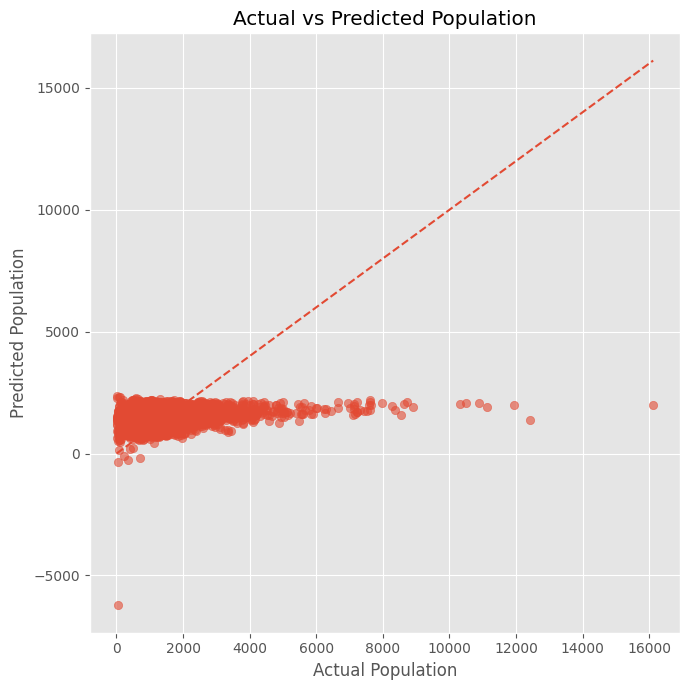

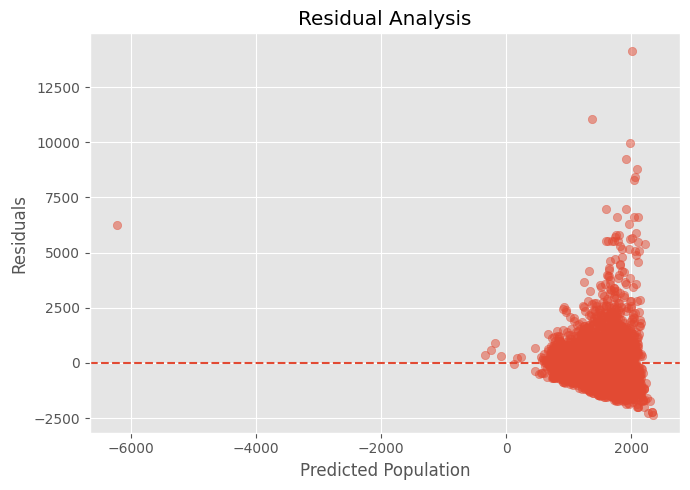

,Actual Population,Predicted Population
0,1392.0,1601.493735
1,1565.0,1410.619747
2,1310.0,853.581487
3,1705.0,1710.459495
4,1063.0,1271.154466
5,2400.0,1905.169555
6,670.0,1171.786535
7,1011.0,1189.774292
8,1050.0,2208.875312
9,943.0,879.438841


In [2]:
# ============================================
# MISSION 1: THE URBAN PLANNER
# Linear Regression on California Housing Data
# ============================================

# -------- Step 1: Import Libraries --------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

plt.style.use('ggplot')

# -------- Step 2: Load Dataset --------
housing_data = fetch_california_housing(as_frame=True)
df = housing_data.frame

# -------- Step 3: Explore Dataset --------
print("Dataset Shape:", df.shape)
df.info()
df.describe()

# -------- Step 4: Feature & Target Selection --------
X = df[['HouseAge', 'AveRooms']]
y = df['Population']

# -------- Step 5: Train-Test Split --------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# -------- Step 6: Train Linear Regression Model --------
model = LinearRegression()
model.fit(X_train, y_train)

# -------- Step 7: Predictions --------
y_pred = model.predict(X_test)

# -------- Step 8: Model Evaluation --------
r2 = r2_score(y_test, y_pred)
print("R² Score:", round(r2, 4))

# -------- Step 9: Coefficient Analysis --------
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Regression Coefficient': model.coef_
})
print(coefficients)

# -------- Step 10: Actual vs Predicted Plot --------
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')
plt.xlabel("Actual Population")
plt.ylabel("Predicted Population")
plt.title("Actual vs Predicted Population")
plt.tight_layout()
plt.show()

# -------- Step 11: Residual Plot --------
residuals = y_test - y_pred

plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted Population")
plt.ylabel("Residuals")
plt.title("Residual Analysis")
plt.tight_layout()
plt.show()

# -------- Step 12: Sample Prediction Comparison --------
comparison = pd.DataFrame({
    'Actual Population': y_test.values[:10],
    'Predicted Population': y_pred[:10]
})
comparison
